# 1 Import Libraries

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/krupalpatel07/gold-price-dynamics/GoldUSD.csv


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

import plotly.graph_objects as go
import plotly.express as px

from sklearn.cluster import KMeans
from mpl_toolkits.mplot3d import Axes3D

plt.style.use("dark_background")

# 2 Load Dataset

In [3]:
df = pd.read_csv("/kaggle/input/datasets/krupalpatel07/gold-price-dynamics/GoldUSD.csv")

df['Date'] = pd.to_datetime(df['Date'])

df = df.sort_values("Date")

df.set_index("Date", inplace=True)

df.head()

/tmp/ipykernel_55/3162073543.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'])


,Open,High,Low,Close,Volume
Date,,,,,
2000-01-09,277.000000,277.000000,277.000000,277.000000,0
2000-01-11,263.899994,263.899994,263.899994,263.899994,0
2000-01-12,269.700012,272.000000,268.500000,268.700012,332
2000-02-10,272.799988,273.500000,272.500000,273.100006,161
2000-02-11,264.399994,264.399994,264.399994,264.399994,0


# 3 Basic Market Structure

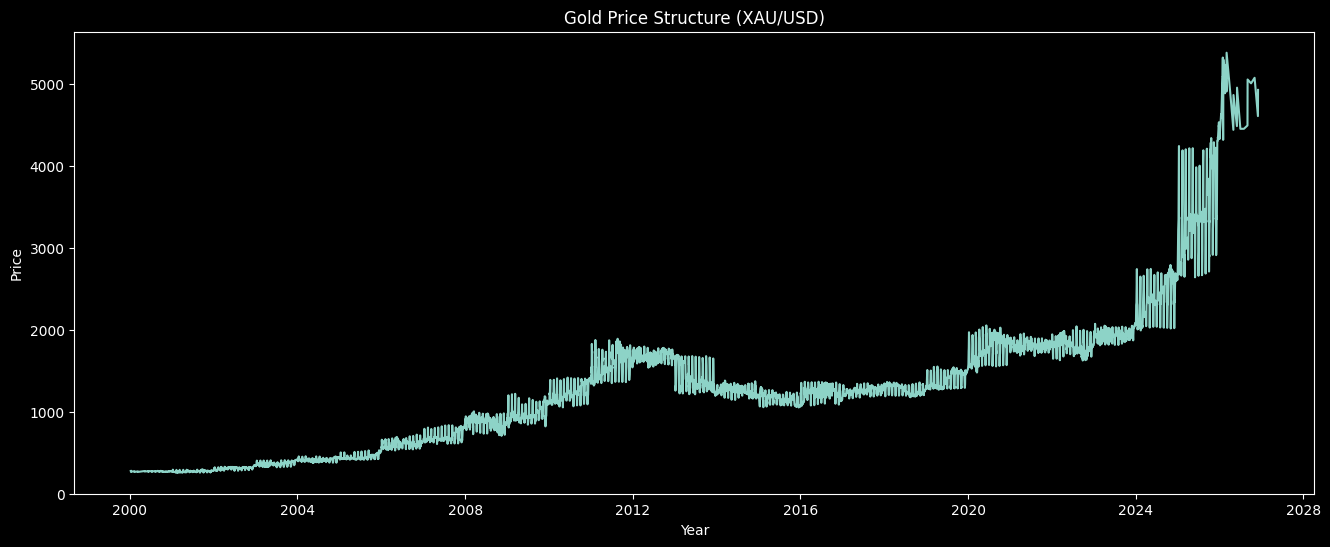

In [4]:
plt.figure(figsize=(16,6))

plt.plot(df['Close'])

plt.title("Gold Price Structure (XAU/USD)")
plt.xlabel("Year")
plt.ylabel("Price")

plt.show()

# 4 Interactive Candlestick Chart

In [5]:
fig = go.Figure(data=[go.Candlestick(
    x=df.index,
    open=df['Open'],
    high=df['High'],
    low=df['Low'],
    close=df['Close']
)])

fig.update_layout(title="Gold Market Structure")

fig.show()

# 5 Log Price Behavior

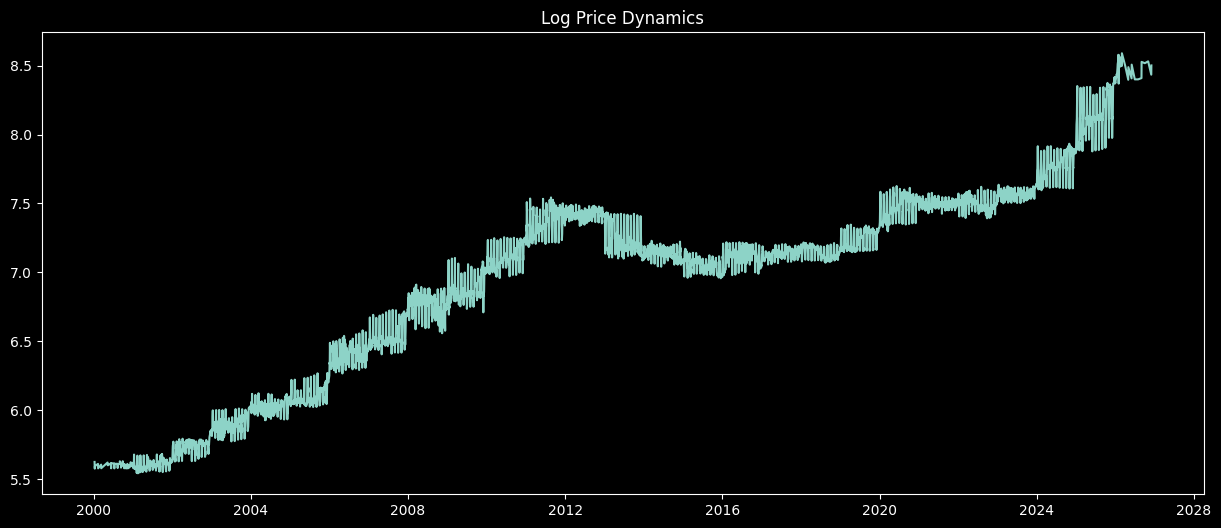

In [6]:
plt.figure(figsize=(15,6))

plt.plot(np.log(df['Close']))

plt.title("Log Price Dynamics")

plt.show()

# 6 Daily Returns

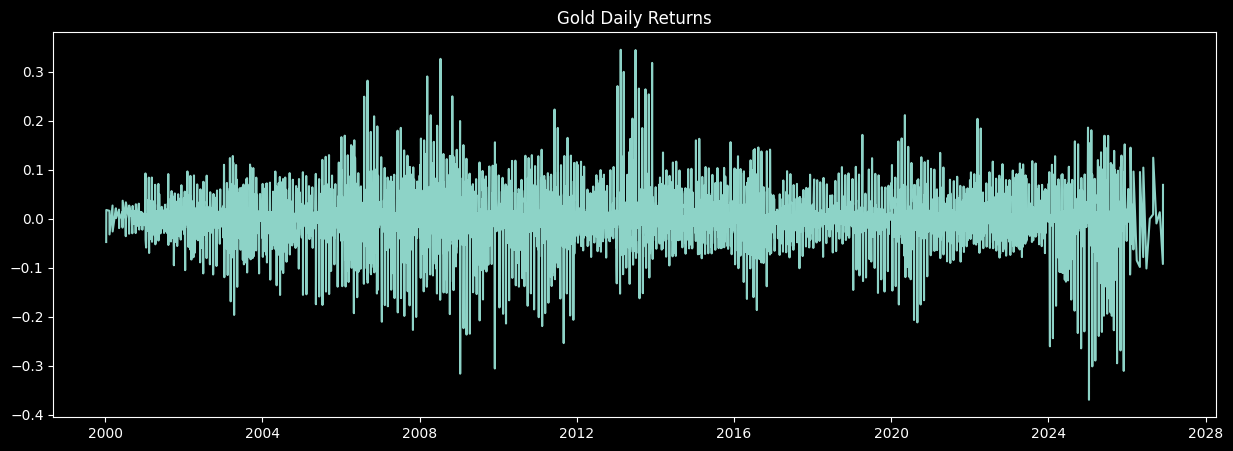

In [7]:
returns = df['Close'].pct_change()

plt.figure(figsize=(15,5))

plt.plot(returns)

plt.title("Gold Daily Returns")

plt.show()

# 7 Return Distribution

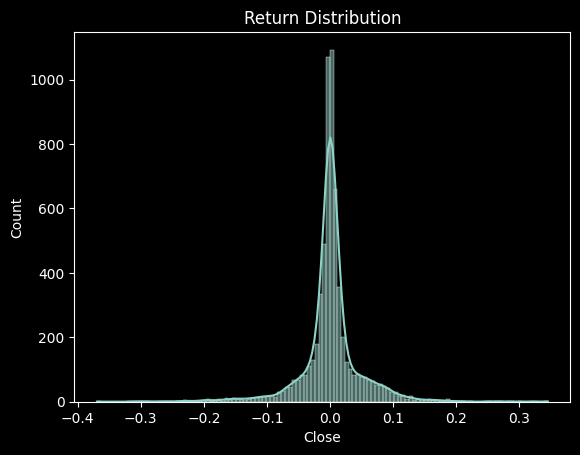

In [8]:
sns.histplot(returns.dropna(), bins=120, kde=True)

plt.title("Return Distribution")

plt.show()

# 8 Volatility Clustering

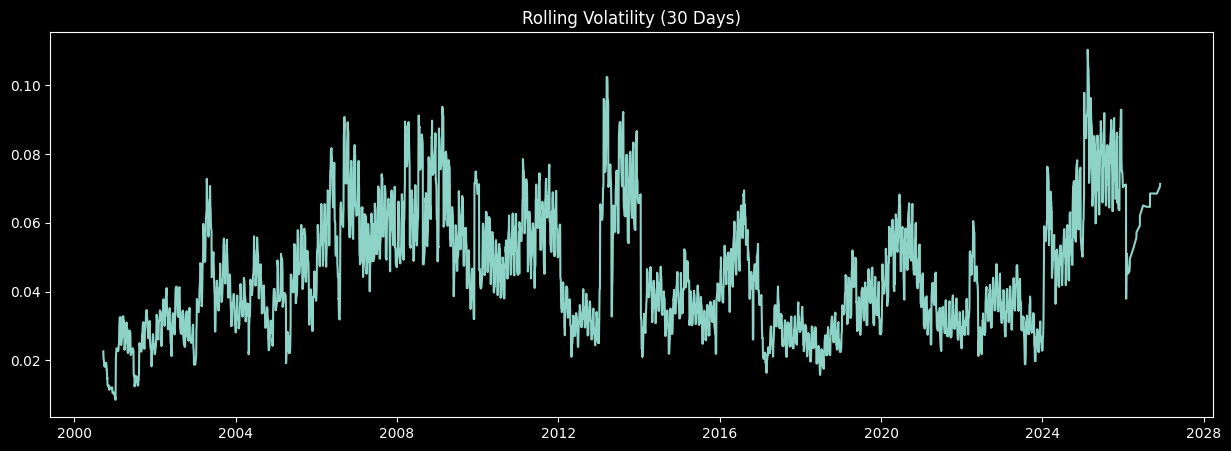

In [9]:
volatility = returns.rolling(30).std()

plt.figure(figsize=(15,5))

plt.plot(volatility)

plt.title("Rolling Volatility (30 Days)")

plt.show()

# 9 Moving Average Market Trend

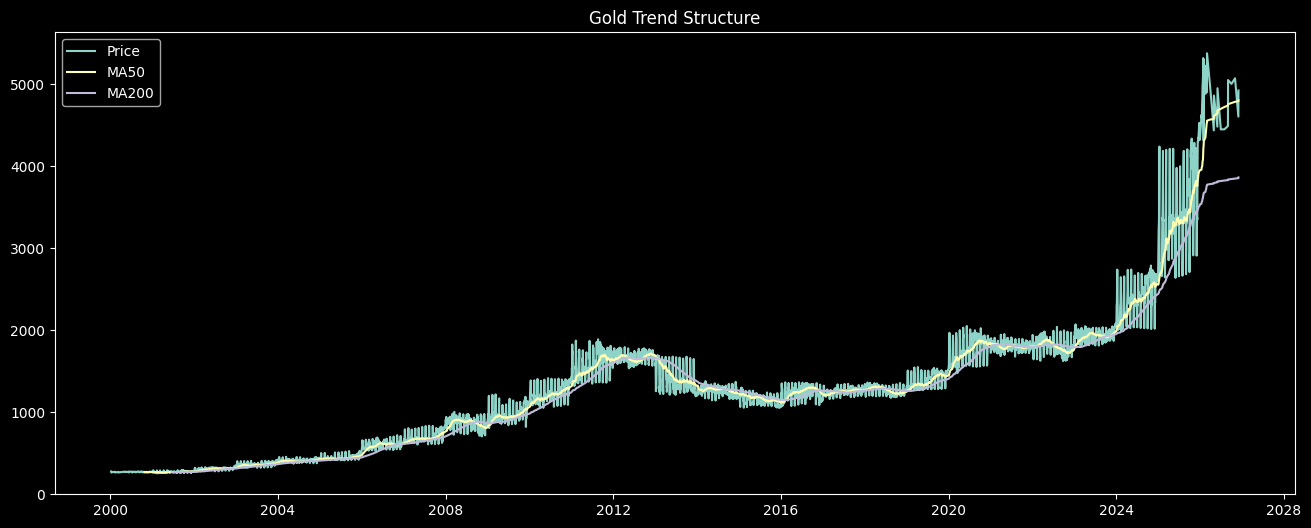

In [10]:
df['MA50'] = df['Close'].rolling(50).mean()
df['MA200'] = df['Close'].rolling(200).mean()

plt.figure(figsize=(16,6))

plt.plot(df['Close'], label="Price")
plt.plot(df['MA50'], label="MA50")
plt.plot(df['MA200'], label="MA200")

plt.legend()

plt.title("Gold Trend Structure")

plt.show()

# 10 Volume vs Price

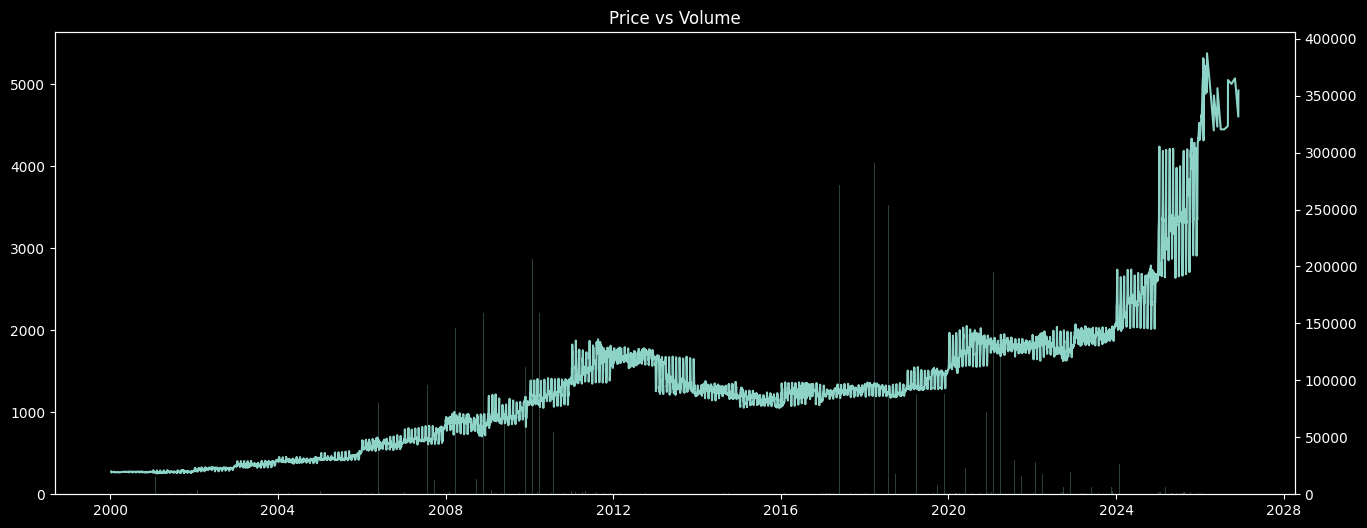

In [11]:
fig, ax1 = plt.subplots(figsize=(16,6))

ax1.plot(df['Close'])

ax2 = ax1.twinx()

ax2.bar(df.index, df['Volume'], alpha=0.3)

plt.title("Price vs Volume")

plt.show()

# 11 Correlation Heatmap

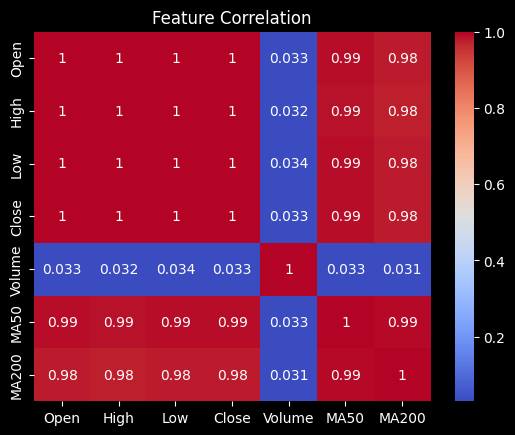

In [12]:
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")

plt.title("Feature Correlation")

plt.show()

# 12 Monthly Seasonality

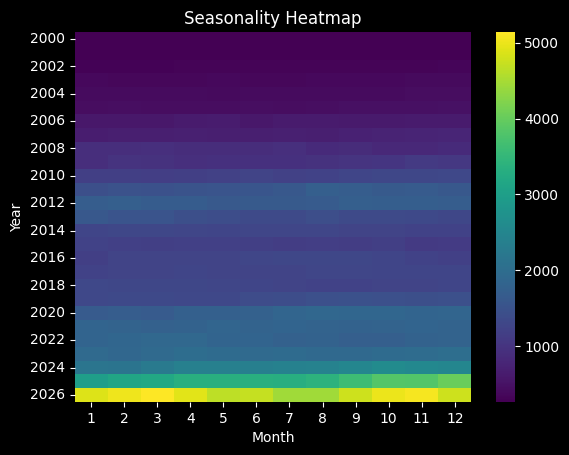

In [13]:
df['Month'] = df.index.month
df['Year'] = df.index.year

pivot = df.pivot_table(values='Close', index='Year', columns='Month')

sns.heatmap(pivot, cmap="viridis")

plt.title("Seasonality Heatmap")

plt.show()

# 13 Market Regime Detection (Clustering)

In [14]:
features = pd.DataFrame()

features['returns'] = returns
features['volatility'] = returns.rolling(20).std()

features = features.dropna()

kmeans = KMeans(n_clusters=3)

features['regime'] = kmeans.fit_predict(features)

## Regime Visualization

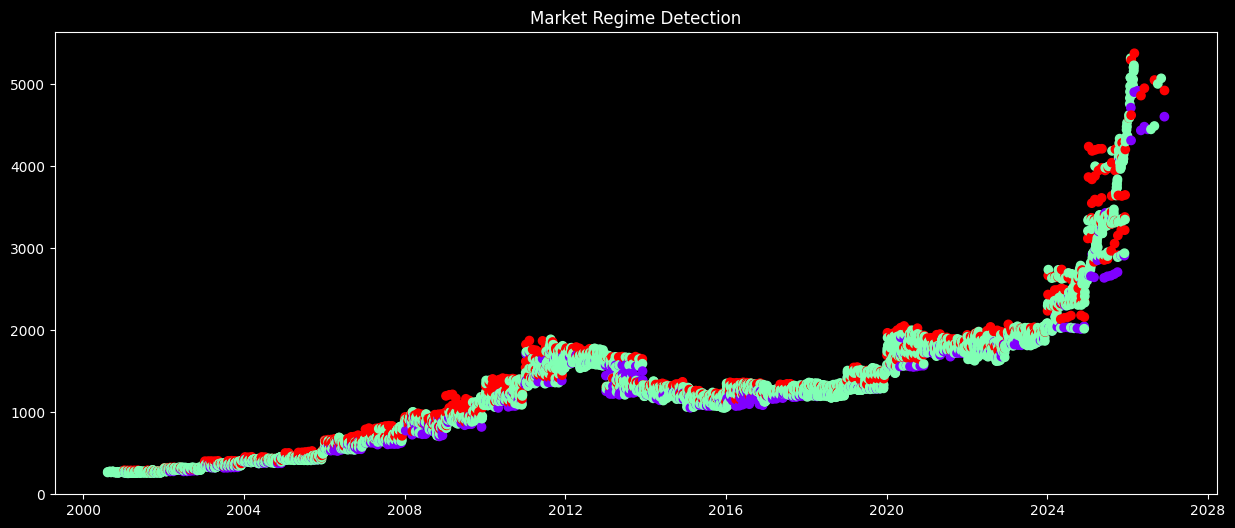

In [15]:
plt.figure(figsize=(15,6))

plt.scatter(features.index,
            df.loc[features.index]['Close'],
            c=features['regime'],
            cmap='rainbow')

plt.title("Market Regime Detection")

plt.show()

# 14 Volatility Heatmap

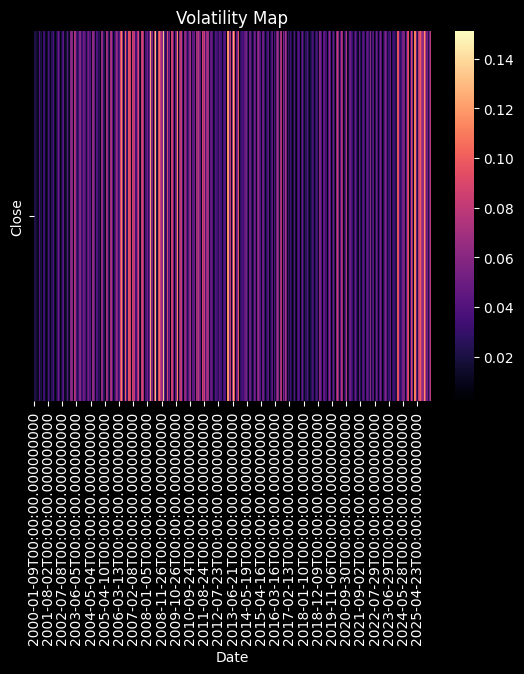

In [17]:
vol_map = returns.rolling(10).std()

sns.heatmap(vol_map.to_frame().T, cmap="magma")

plt.title("Volatility Map")

plt.show()

# 15 3D Financial Surface

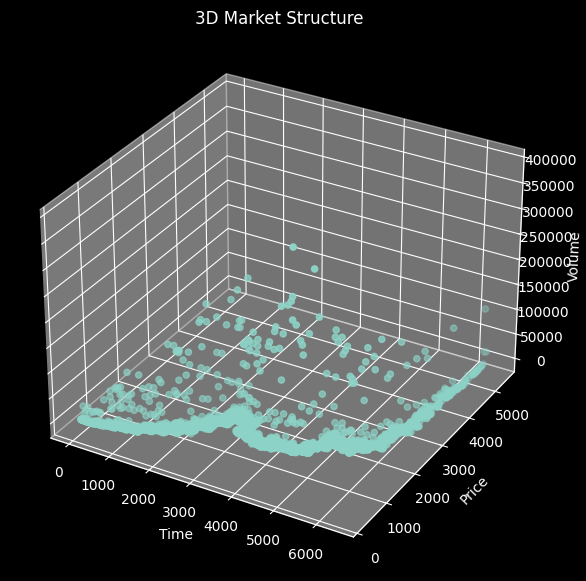

In [16]:
fig = plt.figure(figsize=(10,7))

ax = fig.add_subplot(111, projection='3d')

x = np.arange(len(df))
y = df['Close']
z = df['Volume']

ax.scatter(x, y, z)

ax.set_xlabel("Time")
ax.set_ylabel("Price")
ax.set_zlabel("Volume")

plt.title("3D Market Structure")

plt.show()

# 16 Interactive Price Explorer

In [18]:
fig = px.line(df, x=df.index, y='Close',
              title="Interactive Gold Price Chart")

fig.show()

# 17 Rolling Sharpe Ratio

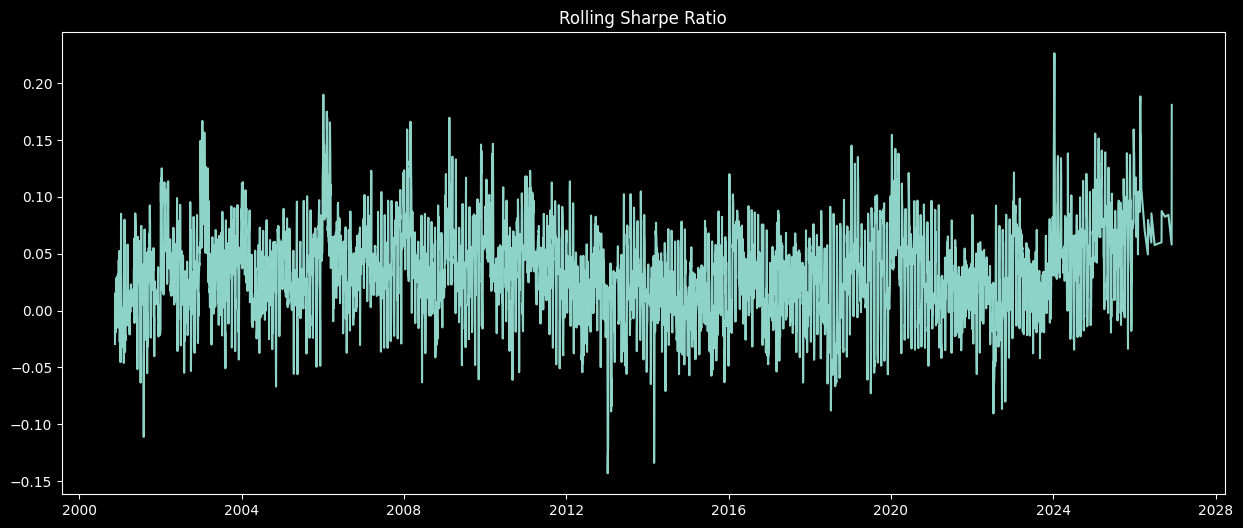

In [19]:
sharpe = returns.rolling(60).mean() / returns.rolling(60).std()

plt.figure(figsize=(15,6))

plt.plot(sharpe)

plt.title("Rolling Sharpe Ratio")

plt.show()

# 18 Drawdown Analysis

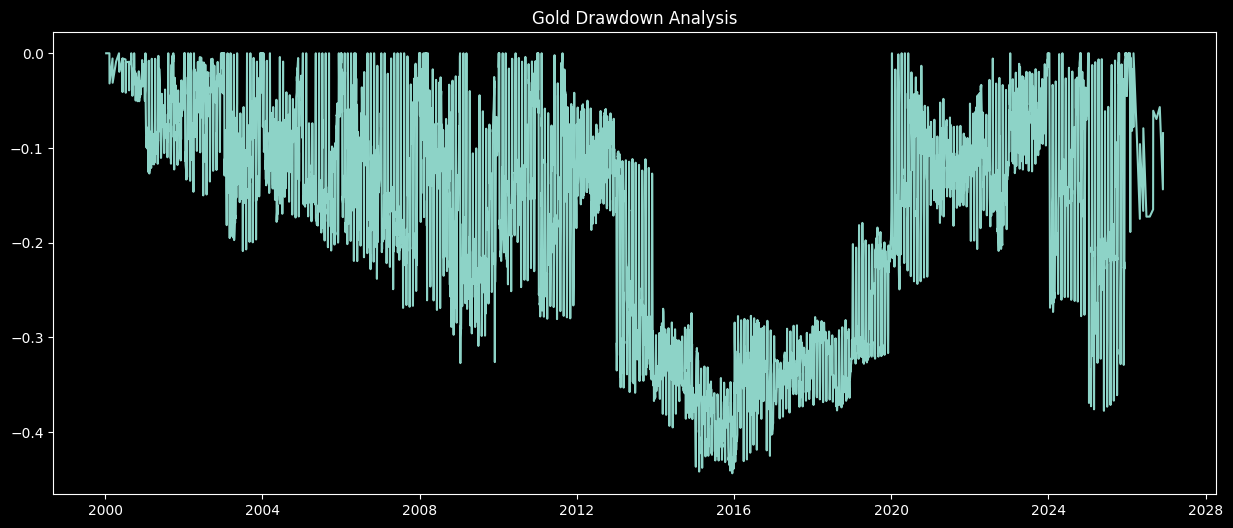

In [20]:
cum = (1 + returns).cumprod()

peak = cum.cummax()

drawdown = (cum - peak) / peak

plt.figure(figsize=(15,6))

plt.plot(drawdown)

plt.title("Gold Drawdown Analysis")

plt.show()

# Conclusion

#### Key Insights:

* Gold markets exhibit strong volatility clustering typical of financial time series.

* Regime detection highlights periods of distinct market behavior such as trending markets, consolidation   phases, and high-volatility environments.

* Seasonality patterns appear in certain months, suggesting macroeconomic influences.

* Advanced visualization provides deeper understanding of market dynamics before model construction.